# SVR para datos fenotipicos y climaticos en PCA y heatmap

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import os
import sys

module_path = os.path.abspath(os.path.join("../../"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [44]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

## Carga de Archivo y preparar trainig and test

In [5]:
file_csv_original = {
    "phenotypic":           "../../../data/obregon_1516_1617/original/o_57_o_phenotypic.csv",
    "phenotypic_weather_d": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_d.csv",
    "phenotypic_weather_w": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_w.csv",
    "phenotypic_weather_f": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_f.csv",
    "phenotypic_weather_m": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_m.csv",
}

file_csv_heatmap = {
    "phenotypic":           "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic.csv",
    "phenotypic_weather_d": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_d.csv",
    "phenotypic_weather_w": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_w.csv",
    "phenotypic_weather_f": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_f.csv",
    "phenotypic_weather_m": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_m.csv",
}

## Original data

### Phenotypic

#### Kernel Lineal

In [45]:
file_csv = file_csv_original["phenotypic"]
title_plot_true_predict = "SVR lineal original phenotypic"
ml = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)

In [46]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [51]:
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [48]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 41.009502633528776
R2 -> 0.8253961171034333
MAPE -> 0.04262825203084962


{'d2_absolute_error_score': 0.6325338033241452,
 'd2_pinball_score': 0.6325338033241452,
 'd2_tweedie_score': 0.8253961171034333,
 'explained_variance_score': 0.8263753922912421,
 'max_error': 224.5844260924946,
 'mean_absolute_error': 25.6408747731412,
 'mean_absolute_percentage_error': 0.04262825203084962,
 'mean_gamma_deviance': 0.004545107320769056,
 'mean_poisson_deviance': 2.6926818198045157,
 'mean_squared_error': 1681.7793062494034,
 'mean_squared_log_error': 0.004661854314085398,
 'median_absolute_error': 12.433181834970355,
 'r2_score': 0.8253961171034333,
 'root_mean_squared_error': 41.009502633528776,
 'root_mean_squared_log_error': 0.06827777320684528}

Graficas

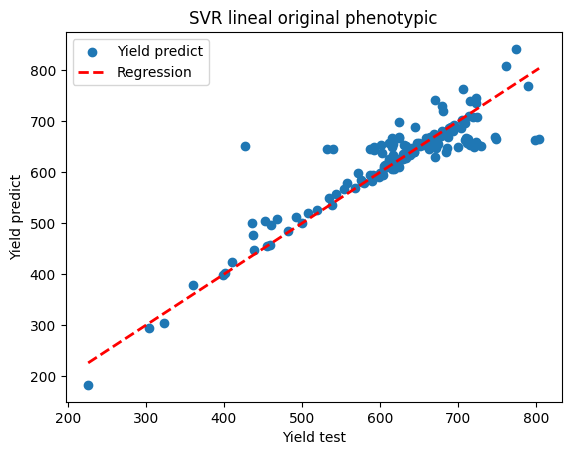

In [49]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [14]:
file_csv = file_csv_original["phenotypic_weather_d"]
title_plot_true_predict = "SVR Original phenotypic weather daily"
ml = SVR_Prediction()

In [15]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [16]:
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [17]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 99.5085009971783
R2 -> -0.02802875202252042
MAPE -> 0.13810037310718154


{'d2_absolute_error_score': 0.018179164857711094,
 'd2_pinball_score': 0.018179164857711094,
 'd2_tweedie_score': -0.02802875202252042,
 'explained_variance_score': 0.04940464385044829,
 'max_error': 405.0873819775843,
 'mean_absolute_error': 68.50900929467318,
 'mean_absolute_percentage_error': 0.13810037310718154,
 'mean_gamma_deviance': 0.031609140261593026,
 'mean_poisson_deviance': 17.434360259196378,
 'mean_squared_error': 9901.941770705434,
 'mean_squared_log_error': 0.03685736284417568,
 'median_absolute_error': 46.852574598227534,
 'r2_score': -0.02802875202252042,
 'root_mean_squared_error': 99.5085009971783,
 'root_mean_squared_log_error': 0.19198271496198735}

Graficas

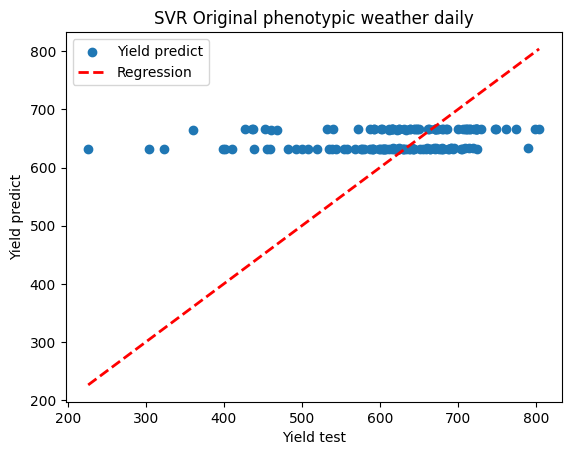

In [18]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [19]:
file_csv = file_csv_original["phenotypic_weather_w"]
title_plot_true_predict = "SVR original phenotypic weather weekly"
ml = SVR_Prediction()

In [20]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Ejecutar la nueva ML

In [21]:
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [23]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 98.19920347337514
R2 -> -0.0011538534843751336
MAPE -> 0.13609403314475627


{'d2_absolute_error_score': 0.03279239958342661,
 'd2_pinball_score': 0.03279239958342661,
 'd2_tweedie_score': -0.0011538534843751336,
 'explained_variance_score': 0.07427142538972831,
 'max_error': 399.6478127733434,
 'mean_absolute_error': 67.4893342197353,
 'mean_absolute_percentage_error': 0.13609403314475627,
 'mean_gamma_deviance': 0.030974521685626345,
 'mean_poisson_deviance': 17.02915593526381,
 'mean_squared_error': 9643.08356280533,
 'mean_squared_log_error': 0.036086100585163865,
 'median_absolute_error': 46.29837467356157,
 'r2_score': -0.0011538534843751336,
 'root_mean_squared_error': 98.19920347337514,
 'root_mean_squared_log_error': 0.18996341907105133}

Graficas

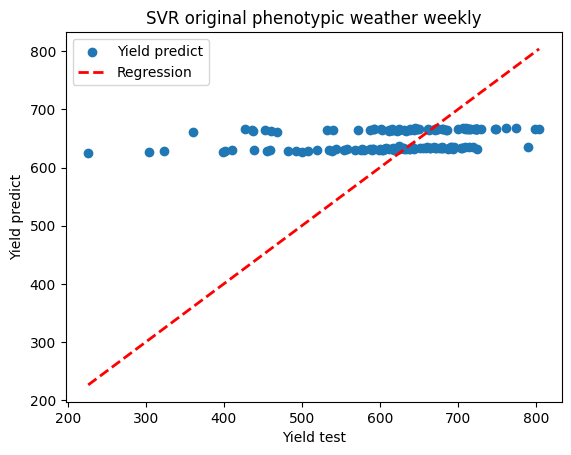

In [24]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [25]:
file_csv = file_csv_original["phenotypic_weather_f"]
title_plot_true_predict = "SVR original phenotypic weather fortnightly"
ml = SVR_Prediction()

In [26]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [27]:

ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [28]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 96.87034011342968
R2 -> 0.025758686494273708
MAPE -> 0.1340082055332289


{'d2_absolute_error_score': 0.04766372873252023,
 'd2_pinball_score': 0.04766372873252023,
 'd2_tweedie_score': 0.025758686494273708,
 'explained_variance_score': 0.09700376107286668,
 'max_error': 394.8644477005888,
 'mean_absolute_error': 66.45164995960066,
 'mean_absolute_percentage_error': 0.1340082055332289,
 'mean_gamma_deviance': 0.030333531863818305,
 'mean_poisson_deviance': 16.621652730760854,
 'mean_squared_error': 9383.862793691544,
 'mean_squared_log_error': 0.035304571520902175,
 'median_absolute_error': 46.0184024998149,
 'r2_score': 0.025758686494273708,
 'root_mean_squared_error': 96.87034011342968,
 'root_mean_squared_log_error': 0.18789510776202284}

Graficas

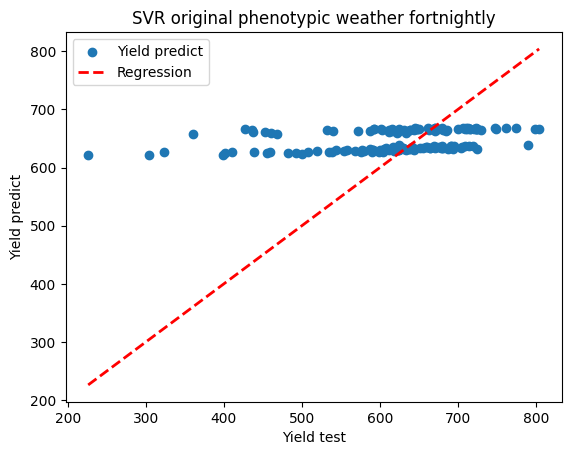

In [29]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [30]:
file_csv = file_csv_original["phenotypic_weather_m"]
title_plot_true_predict = "SVR original phenotypic weather monthly"
ml = SVR_Prediction()

In [31]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [32]:
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [33]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 95.86967600240358
R2 -> 0.04578242237309493
MAPE -> 0.13236916957631253


{'d2_absolute_error_score': 0.06082113759550567,
 'd2_pinball_score': 0.06082113759550567,
 'd2_tweedie_score': 0.04578242237309493,
 'explained_variance_score': 0.11862690918302177,
 'max_error': 392.4319385971228,
 'mean_absolute_error': 65.53355878265242,
 'mean_absolute_percentage_error': 0.13236916957631253,
 'mean_gamma_deviance': 0.029858066881794588,
 'mean_poisson_deviance': 16.318934260109927,
 'mean_squared_error': 9190.994776805835,
 'mean_squared_log_error': 0.0347527676201562,
 'median_absolute_error': 45.63770477553493,
 'r2_score': 0.04578242237309493,
 'root_mean_squared_error': 95.86967600240358,
 'root_mean_squared_log_error': 0.18642094201069848}

Graficas

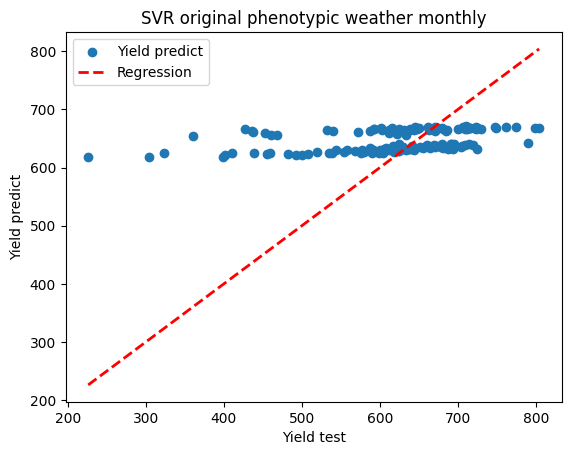

In [34]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

## Heatmap data

### Phenotypic

In [35]:
file_csv = file_csv_heatmap["phenotypic"]
title_plot_true_predict = "SVR heatmap phenotypic"
ml = SVR_Prediction( kernel)

In [36]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [37]:
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [38]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 90.73930831974441
R2 -> 0.1451777417277622
MAPE -> 0.12320344194731193


{'d2_absolute_error_score': 0.13593840801193047,
 'd2_pinball_score': 0.13593840801193047,
 'd2_tweedie_score': 0.1451777417277622,
 'explained_variance_score': 0.20962550053350704,
 'max_error': 401.9092244874289,
 'mean_absolute_error': 60.29206298937613,
 'mean_absolute_percentage_error': 0.12320344194731193,
 'mean_gamma_deviance': 0.02754342299640709,
 'mean_poisson_deviance': 14.83068802000781,
 'mean_squared_error': 8233.622074345636,
 'mean_squared_log_error': 0.03221236577603319,
 'median_absolute_error': 38.84619422488419,
 'r2_score': 0.1451777417277622,
 'root_mean_squared_error': 90.73930831974441,
 'root_mean_squared_log_error': 0.17947803702969672}

Graficas

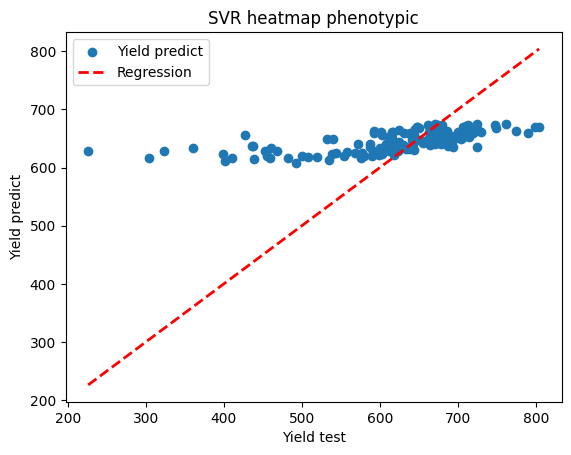

In [39]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [45]:
file_csv = file_csv_heatmap["phenotypic_weather_d"]
title_plot_true_predict = "RF heatmap phenotypic weather daily"

In [46]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [47]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [48]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.721404753208716
R2 -> 0.8675225525204888
MAPE -> 0.03811296448365332


{'d2_absolute_error_score': 0.6850116138642954,
 'd2_pinball_score': 0.6850116138642954,
 'd2_tweedie_score': 0.8675225525204888,
 'explained_variance_score': 0.8697899734031134,
 'max_error': 213.88512089999995,
 'mean_absolute_error': 21.97910402905404,
 'mean_absolute_percentage_error': 0.03811296448365332,
 'mean_gamma_deviance': 0.003604620267094153,
 'mean_poisson_deviance': 2.101285498978764,
 'mean_squared_error': 1276.0187575425623,
 'mean_squared_log_error': 0.0037948759058132513,
 'median_absolute_error': 12.370568950000006,
 'r2_score': 0.8675225525204888,
 'root_mean_squared_error': 35.721404753208716,
 'root_mean_squared_log_error': 0.06160256411719606}

Graficas

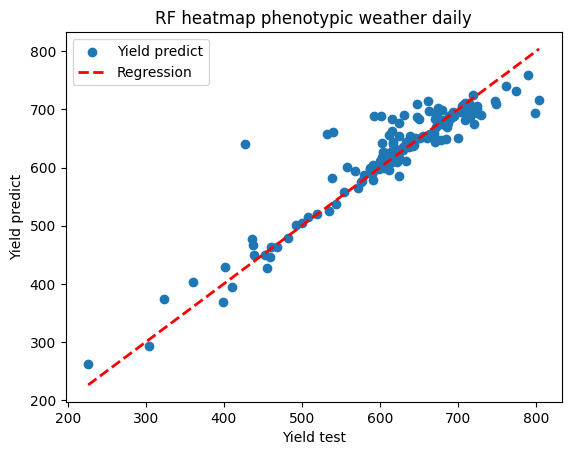

In [49]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [50]:
file_csv = file_csv_heatmap["phenotypic_weather_w"]
title_plot_true_predict = "RF Heatmap phenotypic weather weekly"

In [51]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [52]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [53]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.72176855781117
R2 -> 0.8675198540739483
MAPE -> 0.03818783473527023


{'d2_absolute_error_score': 0.6844524492806574,
 'd2_pinball_score': 0.6844524492806574,
 'd2_tweedie_score': 0.8675198540739483,
 'explained_variance_score': 0.8698663100523225,
 'max_error': 212.82980769999983,
 'mean_absolute_error': 22.01812113918917,
 'mean_absolute_percentage_error': 0.03818783473527023,
 'mean_gamma_deviance': 0.0036083346396782127,
 'mean_poisson_deviance': 2.1025330728194676,
 'mean_squared_error': 1276.0447488978266,
 'mean_squared_log_error': 0.003797124694110961,
 'median_absolute_error': 12.590765400000294,
 'r2_score': 0.8675198540739483,
 'root_mean_squared_error': 35.72176855781117,
 'root_mean_squared_log_error': 0.06162081380597761}

Graficas

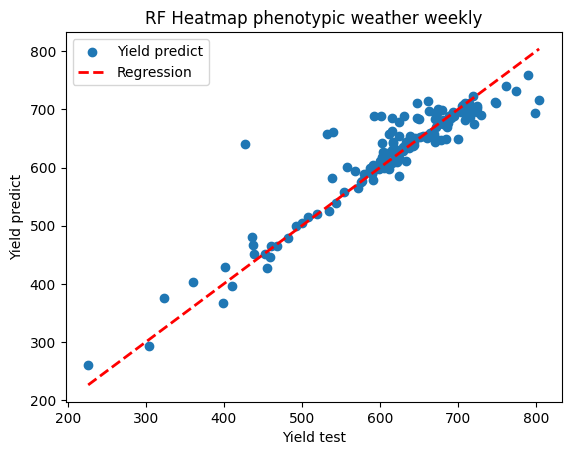

In [54]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [55]:
file_csv = file_csv_heatmap["phenotypic_weather_f"]
title_plot_true_predict = "RF heatmap phenotypic weather fortnightly"

In [56]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [57]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [58]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.83297115114551
R2 -> 0.8666937434356774
MAPE -> 0.03824562499605217


{'d2_absolute_error_score': 0.684110941854772,
 'd2_pinball_score': 0.684110941854772,
 'd2_tweedie_score': 0.8666937434356774,
 'explained_variance_score': 0.8689511598201378,
 'max_error': 214.62414409999997,
 'mean_absolute_error': 22.041950675675622,
 'mean_absolute_percentage_error': 0.03824562499605217,
 'mean_gamma_deviance': 0.0036300415607842355,
 'mean_poisson_deviance': 2.1158674527713064,
 'mean_squared_error': 1284.001821518826,
 'mean_squared_log_error': 0.0038218669638382845,
 'median_absolute_error': 12.16718025000057,
 'r2_score': 0.8666937434356774,
 'root_mean_squared_error': 35.83297115114551,
 'root_mean_squared_log_error': 0.061821250099284505}

Graficas

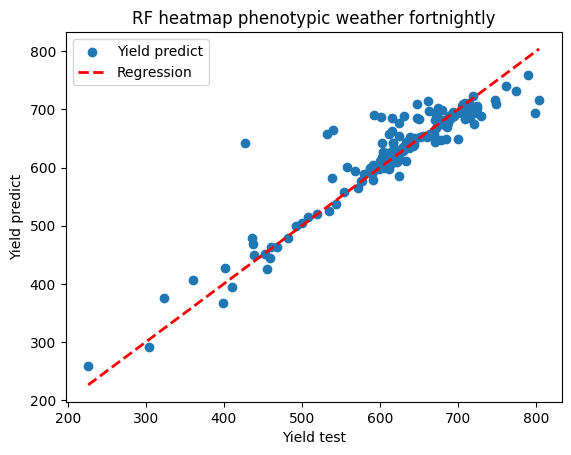

In [59]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [60]:
file_csv = file_csv_heatmap["phenotypic_weather_m"]
title_plot_true_predict = "RF heatmap phenotypic weather monthly"

In [61]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [62]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [63]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.81912897019868
R2 -> 0.866796715243931
MAPE -> 0.038080908061164626


{'d2_absolute_error_score': 0.6850209449419007,
 'd2_pinball_score': 0.6850209449419007,
 'd2_tweedie_score': 0.866796715243931,
 'explained_variance_score': 0.8691342004746274,
 'max_error': 214.69411709999963,
 'mean_absolute_error': 21.978452929729702,
 'mean_absolute_percentage_error': 0.038080908061164626,
 'mean_gamma_deviance': 0.0036069462400243604,
 'mean_poisson_deviance': 2.109897883415238,
 'mean_squared_error': 1283.0100001837268,
 'mean_squared_log_error': 0.00379825845525272,
 'median_absolute_error': 11.962992349999979,
 'r2_score': 0.866796715243931,
 'root_mean_squared_error': 35.81912897019868,
 'root_mean_squared_log_error': 0.06163001261765829}

Graficas

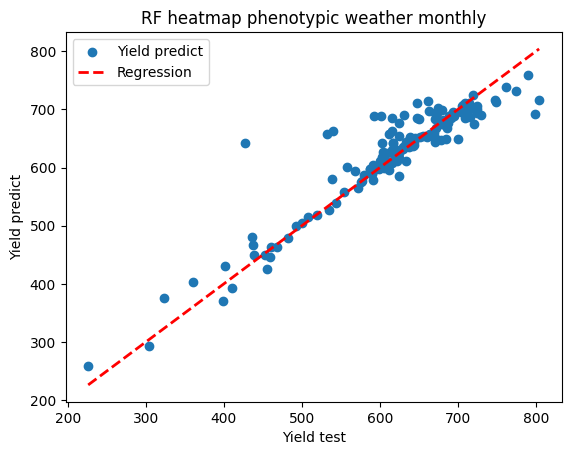

In [64]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

## PCA data

### Phenotypic

In [65]:
file_csv = file_csv_original["phenotypic"]
title_plot_true_predict = "RF PCA phenotypic"

In [66]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Evaluar PCA

In [67]:
pca = preprocessing.get_pca()
pca.number_of_pcs


1

Ejecutar la nueva ML

In [68]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [69]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 58.58726910208235
R2 -> 0.6436379873993064
MAPE -> 0.07618430412057121


{'d2_absolute_error_score': 0.37919176259497867,
 'd2_pinball_score': 0.37919176259497867,
 'd2_tweedie_score': 0.6436379873993064,
 'explained_variance_score': 0.6536960055891781,
 'max_error': 236.77499999999998,
 'mean_absolute_error': 43.318450560714105,
 'mean_absolute_percentage_error': 0.07618430412057121,
 'mean_gamma_deviance': 0.010187593977212469,
 'mean_poisson_deviance': 5.787415592010768,
 'mean_squared_error': 3432.4681008398134,
 'mean_squared_log_error': 0.010604924058429742,
 'median_absolute_error': 32.595379599999774,
 'r2_score': 0.6436379873993064,
 'root_mean_squared_error': 58.58726910208235,
 'root_mean_squared_log_error': 0.10298021197506704}

Graficas

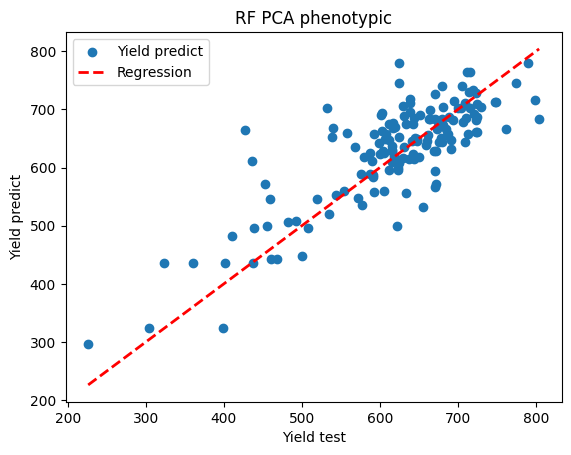

In [70]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [94]:
file_csv = file_csv_original["phenotypic_weather_d"]
title_plot_true_predict = "RF PCA phenotypic weather daily"

In [95]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/develop/app/preprocesses/preprocess.py:48: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260

Ejecutar la nueva ML

In [96]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [97]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 55.46637889115764
R2 -> 0.6805929327874221
MAPE -> 0.07274613000611159


{'d2_absolute_error_score': 0.40534154077512685,
 'd2_pinball_score': 0.40534154077512685,
 'd2_tweedie_score': 0.6805929327874221,
 'explained_variance_score': 0.6859111199846704,
 'max_error': 206.69100000000003,
 'mean_absolute_error': 41.493784254729896,
 'mean_absolute_percentage_error': 0.07274613000611159,
 'mean_gamma_deviance': 0.009351609822502,
 'mean_poisson_deviance': 5.242343477992672,
 'mean_squared_error': 3076.5191872974574,
 'mean_squared_log_error': 0.009661418679106809,
 'median_absolute_error': 32.52398170000038,
 'r2_score': 0.6805929327874221,
 'root_mean_squared_error': 55.46637889115764,
 'root_mean_squared_log_error': 0.09829251588552818}

Graficas

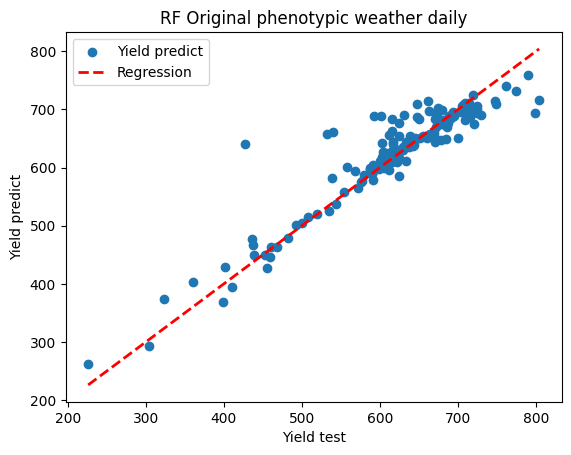

In [75]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [98]:
file_csv = file_csv_original["phenotypic_weather_w"]
title_plot_true_predict = "RF PCA phenotypic weather weekly"

In [99]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
   transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Ejecutar la nueva ML

In [100]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [101]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 54.45375686620966
R2 -> 0.6921489856135049
MAPE -> 0.07265862923779323


{'d2_absolute_error_score': 0.40632717229764304,
 'd2_pinball_score': 0.40632717229764304,
 'd2_tweedie_score': 0.6921489856135048,
 'explained_variance_score': 0.6959574870436145,
 'max_error': 208.62900000000002,
 'mean_absolute_error': 41.42500934517382,
 'mean_absolute_percentage_error': 0.07265862923779323,
 'mean_gamma_deviance': 0.00899263613217698,
 'mean_poisson_deviance': 5.040445375164773,
 'mean_squared_error': 2965.2116368442757,
 'mean_squared_log_error': 0.009295067782650311,
 'median_absolute_error': 32.19365694999726,
 'r2_score': 0.6921489856135049,
 'root_mean_squared_error': 54.45375686620966,
 'root_mean_squared_log_error': 0.09641093186278366}

Graficas

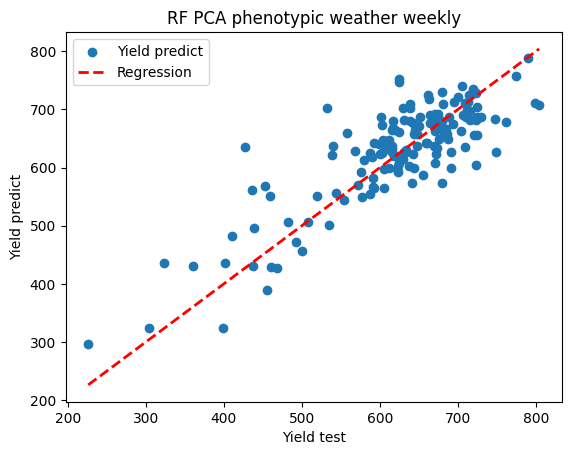

In [102]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [103]:
file_csv = file_csv_original["phenotypic_weather_f"]
title_plot_true_predict = "RF PCA phenotypic weather fortnightly"

In [108]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [109]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [110]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 53.05555890436934
R2 -> 0.7077552749984644
MAPE -> 0.07085967000790759


{'d2_absolute_error_score': 0.42127723150516005,
 'd2_pinball_score': 0.42127723150516005,
 'd2_tweedie_score': 0.7077552749984644,
 'explained_variance_score': 0.7121703185171029,
 'max_error': 207.72500000000002,
 'mean_absolute_error': 40.38183149790878,
 'mean_absolute_percentage_error': 0.07085967000790759,
 'mean_gamma_deviance': 0.008537314343901616,
 'mean_poisson_deviance': 4.781969396043555,
 'mean_squared_error': 2814.8923306550046,
 'mean_squared_log_error': 0.008843373740247584,
 'median_absolute_error': 30.408884650001085,
 'r2_score': 0.7077552749984644,
 'root_mean_squared_error': 53.05555890436934,
 'root_mean_squared_log_error': 0.09403921384320257}

Graficas

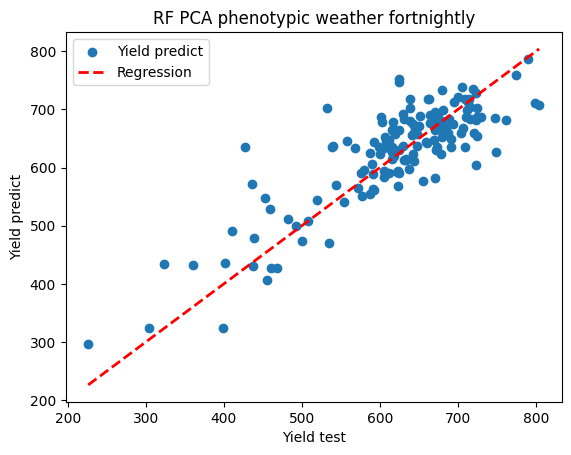

In [111]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [112]:
file_csv = file_csv_original["phenotypic_weather_m"]
title_plot_true_predict = "RF PCA phenotypic weather monthly"

In [113]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [114]:
ml = RF_Prediction()
ml.training(x_train=x_train, y_train=y_train)
y_predicted = ml.prediction(x_test=x_test)

Obtener todas las metricas

In [115]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 56.66811409012759
R2 -> 0.6666024436458611
MAPE -> 0.0754610348603991


{'d2_absolute_error_score': 0.38408011443074064,
 'd2_pinball_score': 0.38408011443074064,
 'd2_tweedie_score': 0.6666024436458611,
 'explained_variance_score': 0.6742717725948327,
 'max_error': 192.394,
 'mean_absolute_error': 42.97735356076776,
 'mean_absolute_percentage_error': 0.0754610348603991,
 'mean_gamma_deviance': 0.00962530068024527,
 'mean_poisson_deviance': 5.438101894905415,
 'mean_squared_error': 3211.275154531717,
 'mean_squared_log_error': 0.009986374152287055,
 'median_absolute_error': 32.42740015000038,
 'r2_score': 0.6666024436458611,
 'root_mean_squared_error': 56.66811409012759,
 'root_mean_squared_log_error': 0.09993184753764466}

Graficas

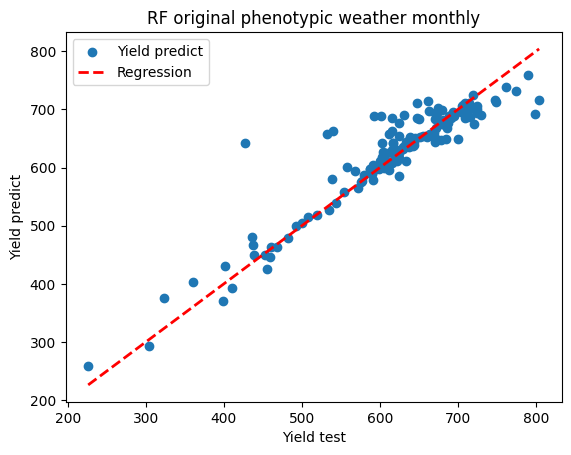

In [90]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)